## Solving (evolving) a hyperbolic PDE system: Fourier basis

In [0]:
import sys
import os
import math
import numpy as np
import scipy

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

# SEABORN & MATPLOTLIBN CONFIGURATION
# seaborn styles (choose by changing index at end)
context=['paper', 'notebook', 'talk', 'poster'] [1]
palette=['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'hls', 'tab10'] [2]
style=['darkgrid', 'whitegrid', 'dark', 'white', 'ticks'] [4] 

# extra customizations
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
# uncomment this to get list of all rc-params: 
#print(plt.rcParams.keys())
rc={"axes.grid":"false", #"true",
    "axes.grid.which": "major",
    "grid.color":'lightgrey',
    "grid.linewidth":0.6,
    'xtick.direction':'in',
    'xtick.top':True,
    'ytick.direction':'in',
    'ytick.right':True
    }

sns.set_theme(style=style,context=context, palette=palette,
              font_scale=1, rc=rc)
print(sys.version)
print("Seaborn version {}".format(sns.__version__))

3.8.16 (default, Jun 12 2023, 18:09:05) 
[GCC 11.2.0]
Seaborn version 0.12.2


In [1]:
import collections

sys.path.append("../Final")
import Fourier
import Chebyshev
import TimeSteppers

In [2]:
# a few pulse profiles that we will use in setting boundary conditions
# and initial data
def wide_pulse_periodic(x, p=4):
    out = np.exp(p * (np.cos(x - 3.5) + 1) - 2 * p)
    dxout = -p * np.sin(x - 3.5) * out
    d2xout = (-p * np.cos(x - 3.5) + p**2 * np.sin(x - 3.5) ** 2) * out
    return out, dxout, d2xout


def wide_pulse(x, p=4):
    out = np.exp(-p / 2 * (x - 3.5) ** 2)
    dxout = -p * (x - 3.5) * out
    d2xout = (-p + p**2 * (x - 3.5) ** 2) * out
    return out, dxout, d2xout


def sharp_pulse_periodic(x, p=12):
    out = np.exp(p * (np.cos(x - 3.5) + 1) - 2 * p)
    dxout = -p * np.sin(x - 3.5) * out
    d2xout = (-p * np.cos(x - 3.5) + p**2 * np.sin(x - 3.5) ** 2) * out
    return out, dxout, d2xout


def sharp_pulse(x, p=12):
    out = 0.7 * np.exp(-p / 2 * (x - 6.5) ** 2)
    dxout = -p * (x - 6.5) * out
    d2xout = (-p + p**2 * (x - 6.5) ** 2) * out
    return out, dxout, d2xout


def zero(x):
    out = x * 0.0  # works for both floats and numpy arrays
    return out, out, out

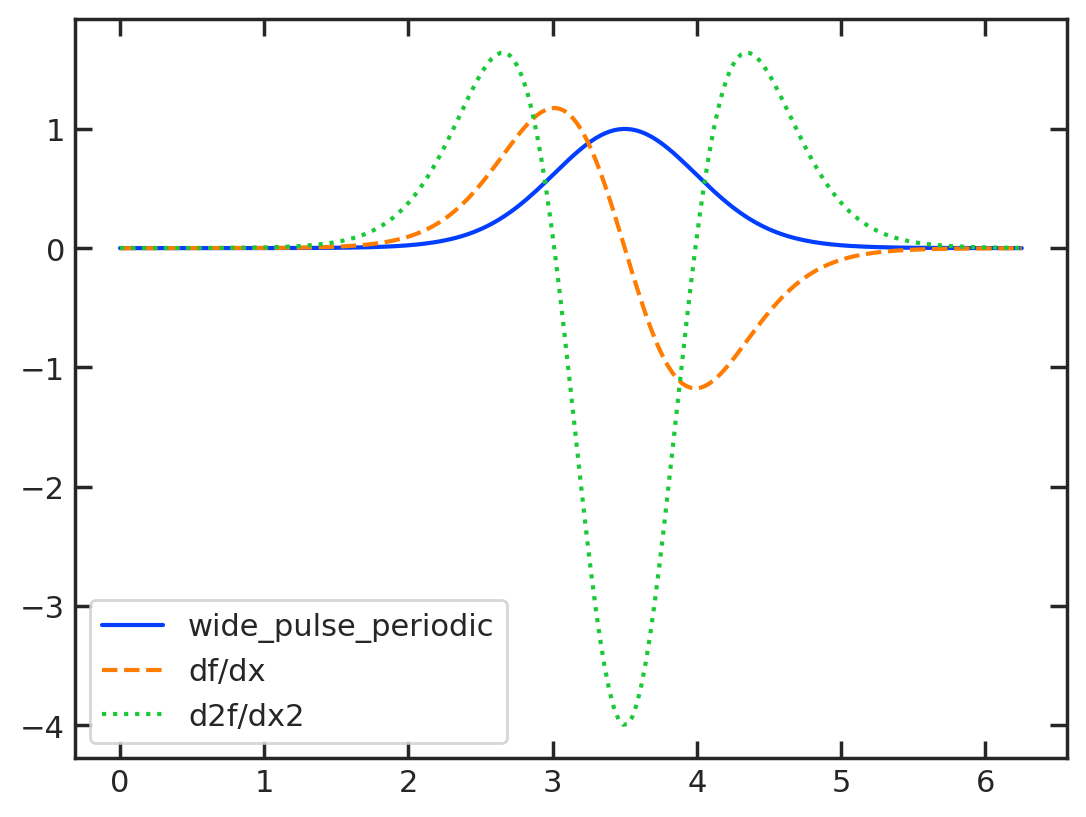

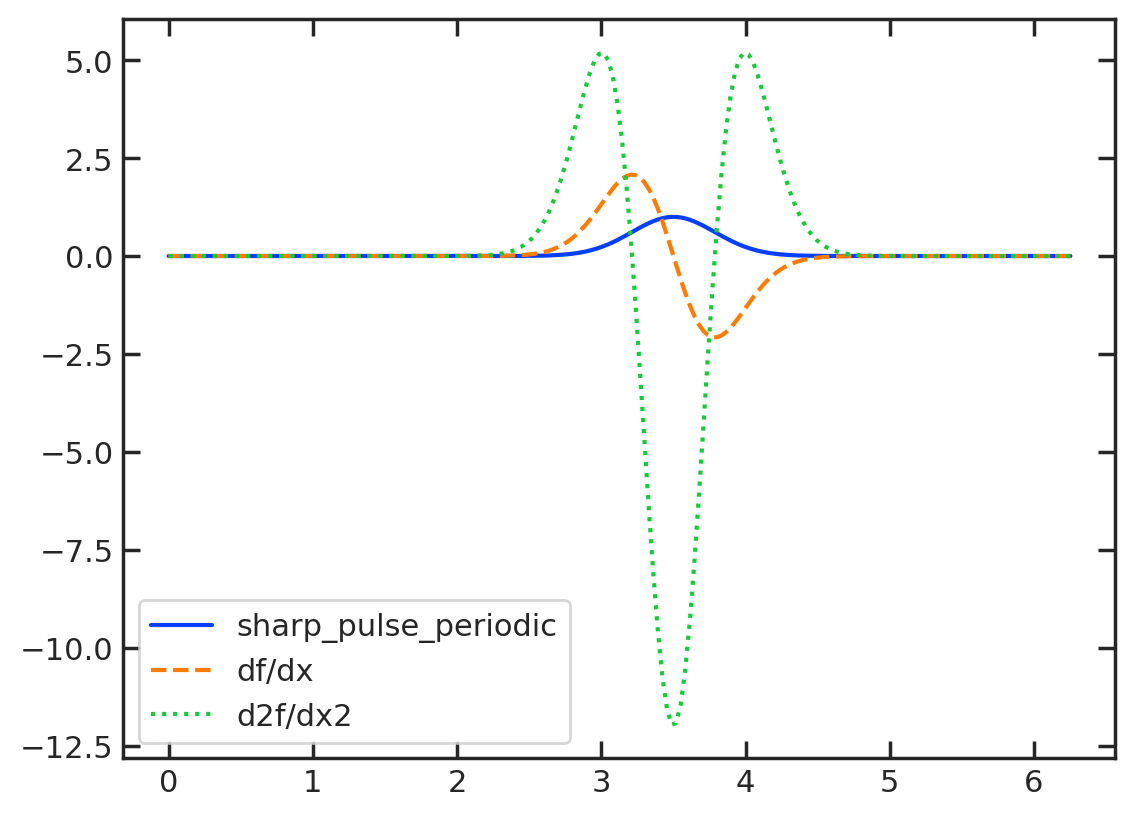

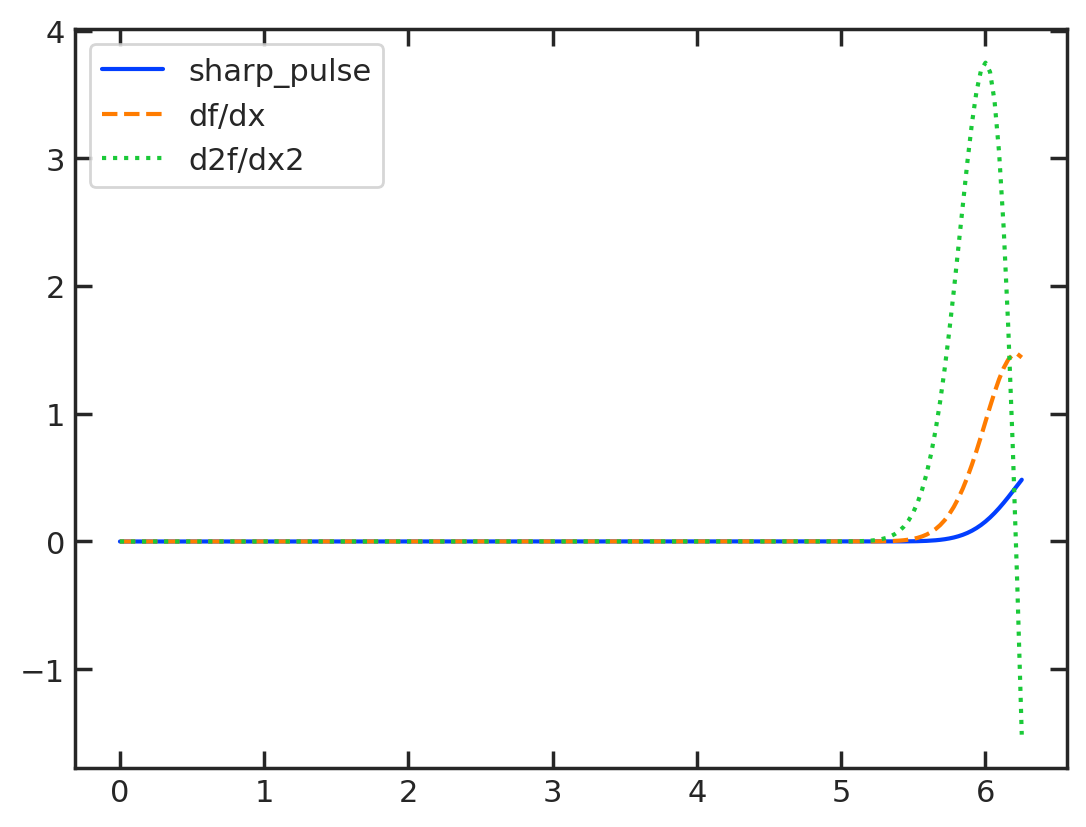

In [3]:
N = 200
x = np.linspace(0, 2 * np.pi, num=N, endpoint=False)

f, df, ddf = wide_pulse_periodic(x)
plt.figure()
plt.plot(x, f, label="wide_pulse_periodic")
plt.plot(x, df, "--", label="df/dx")
plt.plot(x, ddf, ":", label="d2f/dx2")
plt.legend()

f, df, ddf = sharp_pulse_periodic(x)
plt.figure()
plt.plot(x, f, label="sharp_pulse_periodic")
plt.plot(x, df, "--", label="df/dx")
plt.plot(x, ddf, ":", label="d2f/dx2")
plt.legend()

f, df, ddf = sharp_pulse(x)
plt.figure()
plt.plot(x, f, label="sharp_pulse")
plt.plot(x, df, "--", label="df/dx")
plt.plot(x, ddf, ":", label="d2f/dx2")
plt.legend()

In [4]:
Fourier.FourierHelpers_Complex?

Signature: Fourier.FourierHelpers_Complex(N, a=0, b=6.283185307179586)
Docstring:
computes useful objects for coding of spectral methods for
a real-valued Fourier-series truncated at order N/2:

    u(x) = Re (\sum_{n=0}^{N/2} c_n e^{inx})     (1)

CONVENTION:
  storage of the coefficients is in one complex array of length N/2+1
     coefs = [a0, a_1-j*b_1, a_2-j*b_2, ... a_(N/2-1)-j*b_{N/2-1}, a_(N/2)]
  where a_n is the coefficient of cos(n*x), and b_n the coefficient of sin(n*x)

  That means coefs[0] and coefs[N/2] are real, thus we have the full N
  degrees of freedom.
File:      ~/Documents/ICTS/Teaching/2024_Spring__Numerical_Methods/PDE_minicourse_spectral/Demos/Fourier.py
Type:      function

In [5]:
Fourier.FourierHelpers_Complex(10)

(array([0.        , 0.62831853, 1.25663706, 1.88495559, 2.51327412,
        3.14159265, 3.76991118, 4.39822972, 5.02654825, 5.65486678]),
 array([[ 0.1      +0.00000000e+00j,  0.1      +0.00000000e+00j,
          0.1      +0.00000000e+00j,  0.1      +0.00000000e+00j,
          0.1      +0.00000000e+00j,  0.1      +0.00000000e+00j,
          0.1      +0.00000000e+00j,  0.1      +0.00000000e+00j,
          0.1      +0.00000000e+00j,  0.1      +0.00000000e+00j],
        [ 0.2      +0.00000000e+00j,  0.1618034-1.17557050e-01j,
          0.0618034-1.90211303e-01j, -0.0618034-1.90211303e-01j,
         -0.1618034-1.17557050e-01j, -0.2      -2.44929360e-17j,
         -0.1618034+1.17557050e-01j, -0.0618034+1.90211303e-01j,
          0.0618034+1.90211303e-01j,  0.1618034+1.17557050e-01j],
        [ 0.2      +0.00000000e+00j,  0.0618034-1.90211303e-01j,
         -0.1618034-1.17557050e-01j, -0.1618034+1.17557050e-01j,
          0.0618034+1.90211303e-01j,  0.2      +4.89858720e-17j,
          0.061

In [6]:
def RHS_FourierScalarWave(t, u, info):
    """Computes the right-hand-side F(t,u) of the scalar wave
       equation in 1 spatial dimension
         partial_t u = F(t,u)
    with pseudo-spectral methods.  Here u is the vector of data
    with one value per grid-point, assumed to hold:
        u[0] = g
        u[1] = Pi = -dot{g}
        u[2] = Phi = \partial_x g
    We assume a domain x\in [0,2pi[ and periodic boundary
    conditions."""
    D1 = info[3]  # Derivative matrix op

    g, Pi, Phi = u[0], u[1], u[2]
    gDot = -Pi
    PiDot = -Fourier.dudx_Fourier(Phi)
    # PiDot = -D1 @ Phi
    PhiDot = -Fourier.dudx_Fourier(Pi)
    # PhiDot = -D1 @ Pi

    dudt = u.copy()  # create data structure of the same shape as `u`
    dudt[0] = gDot
    dudt[1] = PiDot
    dudt[2] = PhiDot

    # dudt[0][0] = dudt[0][-1] = 0
    # dudt[1][0] = dudt[1][-1] = 0
    # dudt[2][0] = dudt[2][-1] = 0
    return dudt


def Setup_FourierScalarWave(N, profile):
    """Perform the necessary setup for a pseudospectral
    evolution on 'N' grid-points.

    returns
        t, u, info
    where
      - t=0.  the initial time
      - u the solution at t=0 (i.e. the initial guess)
      - info a tuple containing
         - info.dxmin minimal grid-spacing
         - info.x an array of grid-points"""

    # storage for extra info
    SpectralInfo_t = collections.namedtuple(
        "SpectralInfo_t", "dxmin, x, ToSpec, ToPhys, D1, D2"
    )
    # x = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
    x, ToSpec, ToPhys, D1, D2 = Fourier.FourierHelpers_Complex(N, 0, 2 * np.pi)
    info = SpectralInfo_t(
        dxmin=2 * np.pi / N, x=x, ToSpec=ToSpec, ToPhys=ToPhys, D1=D1, D2=D2
    )

    # initial data (right-moving pulse)
    f, df, _ = profile(x)
    g = f
    Pi = df  #  <==== HIGHLIGHT ====
    Phi = df

    u = np.zeros((3, N))
    u[0], u[1], u[2] = g, Pi, Phi
    return 0.0, u, info  # 0 = initial-time

Text(0, 0.5, 'error')

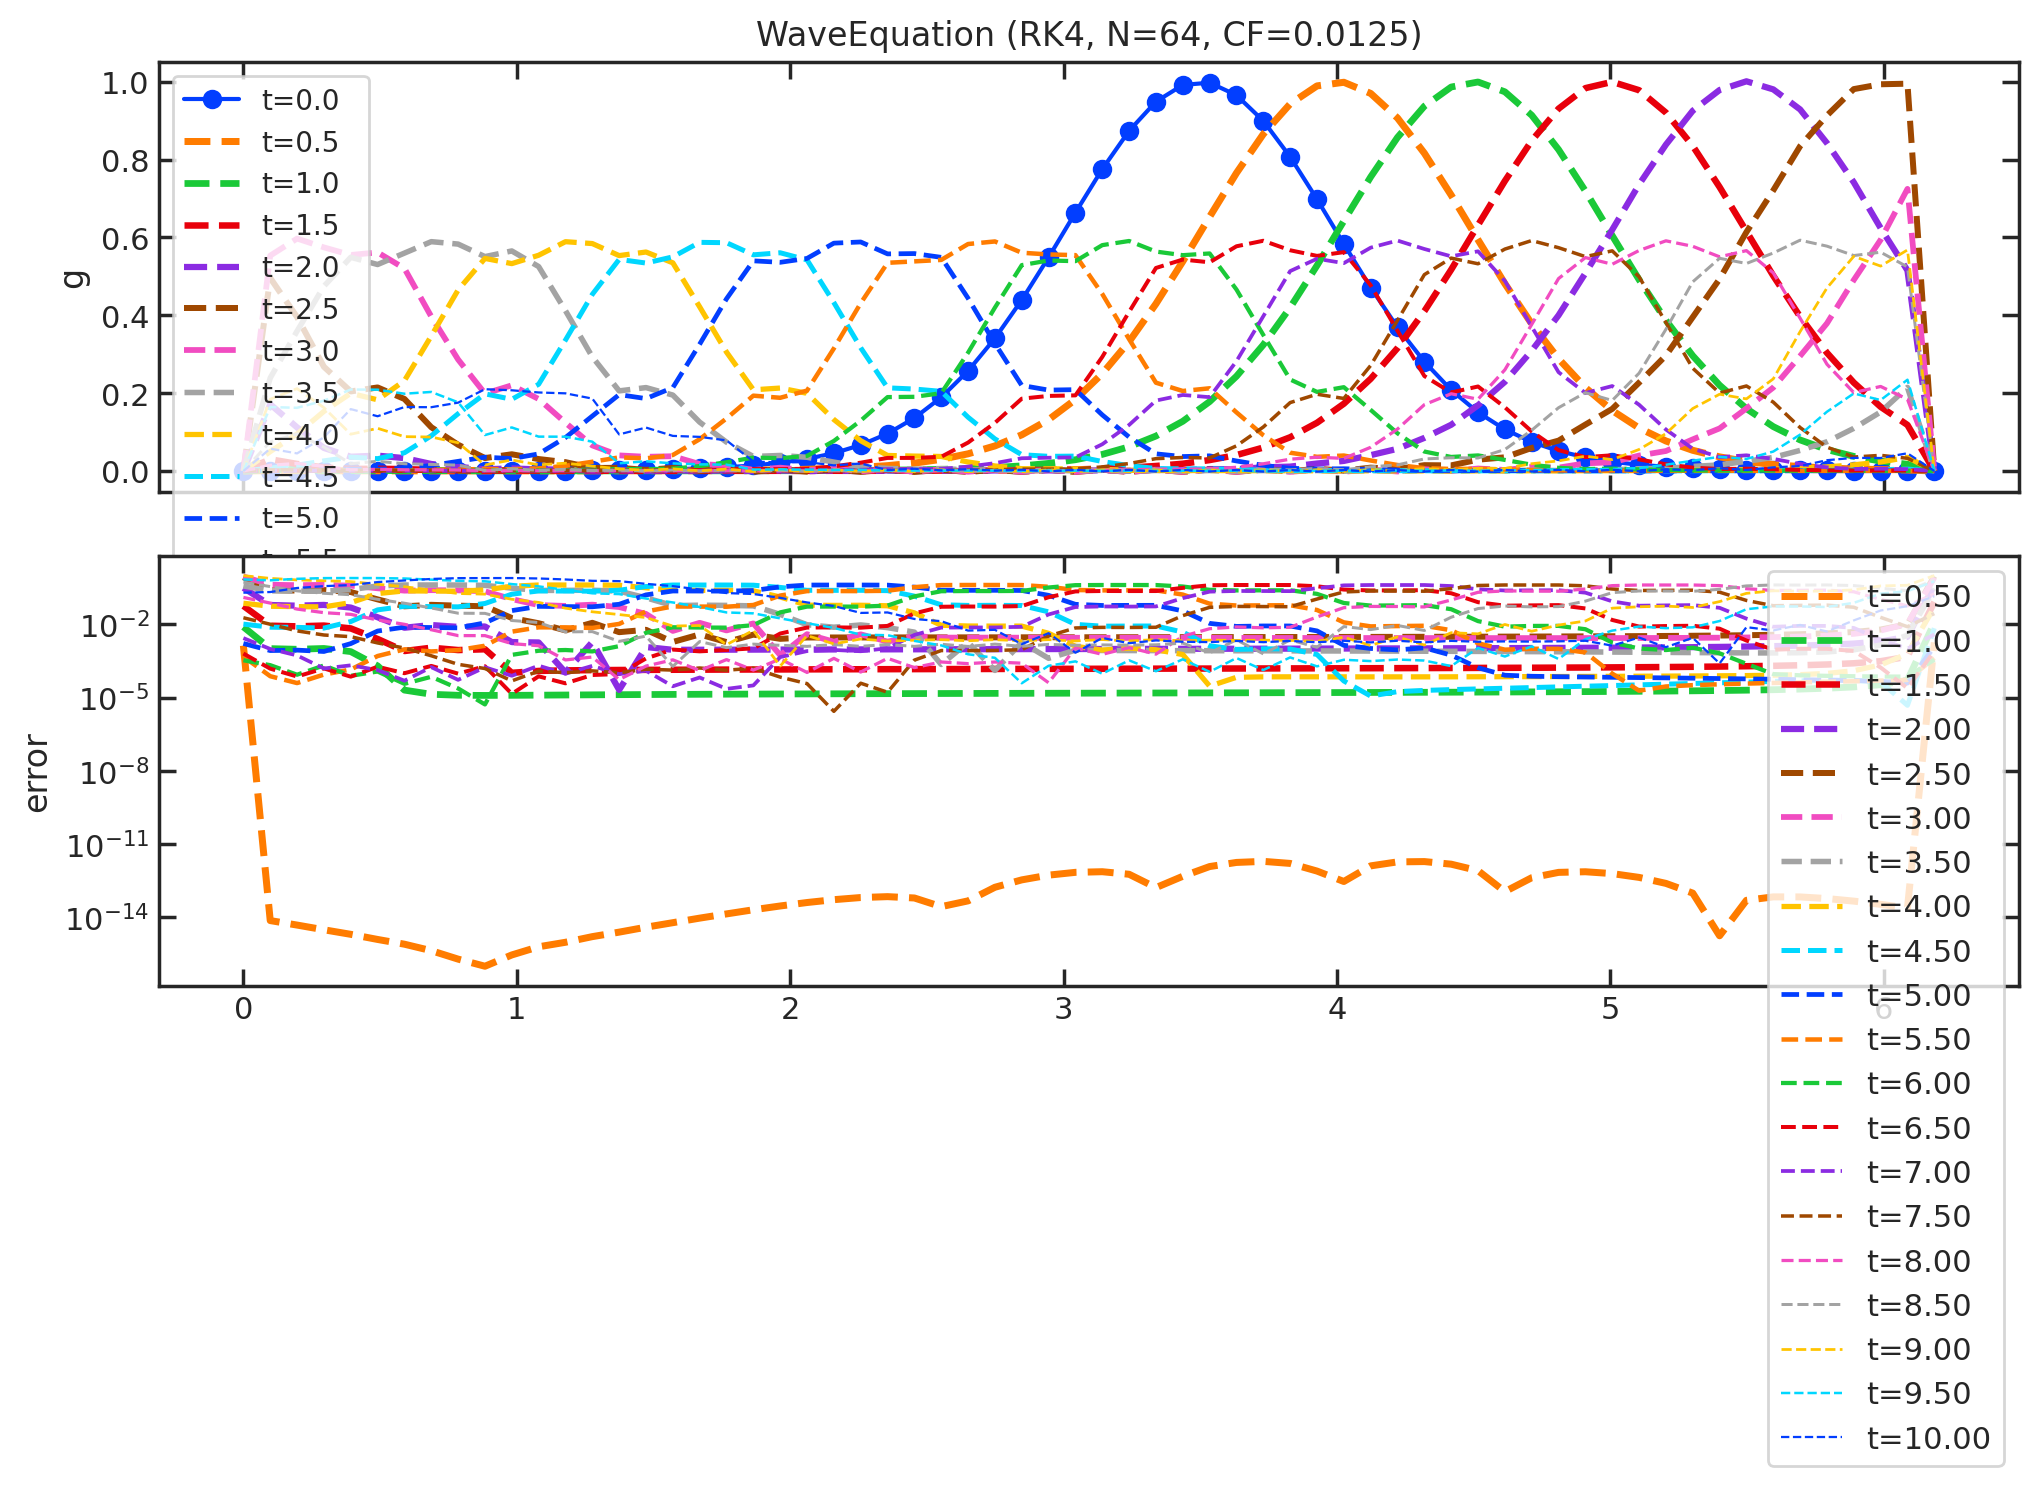

In [11]:
# evolve for a little bit
# fig = plt.figure(figsize=(12, 6))
# gs = fig.add_gridspec(2, hspace=0.15)
# axs = gs.subplots(sharex=True)

Ns = [64]  # resolution
CF = 1 / 80
profile = wide_pulse_periodic
tstepper = TimeSteppers.RK4_Step
tstepper_label = "RK4"
errN = {}  # error at fixed N  vs. CF

for N in [64]: #, 24, 28, 32, 36, 48]:
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, hspace=0.15)
    axs = gs.subplots(sharex=True)
    
    t, u, info = Setup_FourierScalarWave(N, profile=profile)
    g, Pi, Phi = (
        u  # this interprets the top-level length 3 of u as a list, and assigns elements
    )
    axs[0].set_title(f"WaveEquation ({tstepper_label}, N={N}, CF={CF})")
    axs[0].plot(info.x, g, "o-", label=f"t={t:.1f}")

    g_out = [g]
    N_cycles = 20
    for i in range(N_cycles):
        t, u = TimeSteppers.Evolve(
            t, t + 0.5, u, RHS_FourierScalarWave, tstepper, CF, info
        )
        g, pi, phi = u[0], u[1], u[2]
        
        # Boundary Conditions - periodic BCs
        u[0][0] = u[0][-1] = 0
        u[1][0] = u[1][-1] = 0
        u[2][0] = u[2][-1] = 0
        g_out.append(g)
        # C = phi - Fourier.dudx_Fourier(g)
        # plt.plot(info.x, C, label=f"C, t={t:.3f}")
        p = axs[0].plot(
            info.x, g, "--", lw=1.8 * (1.4 - i / N_cycles), label=f"t={t:.1f}"
        )

        # analytic solution (right-moving pulse)
        g_exact, _, _ = profile(info.x - t)
        axs[1].semilogy(
            info.x,
            abs(g - g_exact),
            "--",
            c=p[0].get_color(),
            lw=1.8 * (1.4 - i / N_cycles),
            label=f"t={t:.2f}",
        )
        
    axs[0].legend()
    axs[1].legend()

# on the right, plot error at end
# axs[1].plot(info.x, u[0] - AnalyticSolution(info.x, t), label=f"error at t={t:0.3f}")

# axs[0].set_title(f"Fourier WaveEquation ({tstepper_label}, N={N}, CF={CF})")
axs[0].set_ylabel("g")
axs[0].legend(fontsize="smaller", loc='upper left')
axs[1].set_ylabel("error")
# axs[1].set_xlim(right=7.6)
# axs[1].legend();

In [8]:
info.x

array([0.        , 0.31415927, 0.62831853, 0.9424778 , 1.25663706,
       1.57079633, 1.88495559, 2.19911486, 2.51327412, 2.82743339,
       3.14159265, 3.45575192, 3.76991118, 4.08407045, 4.39822972,
       4.71238898, 5.02654825, 5.34070751, 5.65486678, 5.96902604])

In [9]:
info.x

array([0.        , 0.31415927, 0.62831853, 0.9424778 , 1.25663706,
       1.57079633, 1.88495559, 2.19911486, 2.51327412, 2.82743339,
       3.14159265, 3.45575192, 3.76991118, 4.08407045, 4.39822972,
       4.71238898, 5.02654825, 5.34070751, 5.65486678, 5.96902604])